# SML 

# MULTI CLASS CLASSIFICATION 

# Binary Classification 
- target ustuni 2 ta qiymatdan iborat bo`ladi: Misol uchun Ha / yo`q, 0/1 
- Confusion Matrix ni tushunish oson 
- 0/1 lardan iborat bo`lgani uchun modelni tushunish juda yengil 
- faqt bitta classifier modelni talab qiladi 


# Multi Class Classification 
- target ustunida 4 yoki 5 ta classdan iborat bo`ladi : Misol uchun: {0, 1, 2, 3}
- 3 ta classdan 6 ta classgacha bo`lsa demak multi class bo`ladi 


# Buzda  shu joyda muammo kelib chiqadi chunki bizni modellarimiz faqatgina binary class bilan ishlashga mo`ljallangan 

# Demak ushbu muammoni oldini olish uchun biz buni binary classga o`girib olishimiz kerak 

# Buning quyidagicha usullari bor 
- One vs Rest == OVR 
- One vs One == OVO 

# Real hayotda ko`pincha multi class xolatklar ko`p uchraydi 

# OVR 

# OVR - biz bir classification modelni xar bir class uchun train qilamiz va bu yerda u bir classni qolganlari yig`indisidan (rest) farqini o`rganadi 

# Misol uchun : 3 ta class bor edi 
- it 
- mushuk 
- ilon 

- 1-Model: It (Mushuk+ Ilon)
- 2-Model: Ilon (Mushuk+ It)
- 3-Model: Mushuk (It+ Ilon) 

- Shularning hammasi bitta algaritmda bo`ladi 

# OVR 

Prediction 
Model1 -->  It (Mushuk+ Ilon) --> 0.65

Model2 -->  Ilon (Mushuk+ It) --> 0.18

Model3 -->  Mushuk (It+ Ilon) --> 0.25 

Prediction: It 

# OVR ning + va - tamonlari 
- OVR + 
- sodda va ishlatishga oson 
- agar classlar ozrqo bo`lsa tez ishlaydi 
- OVR - 
- imblanaced datsetlar bilan yaxshi ishlamaydi 

# OVO - biz bir classification modelni xar bir class uchun train qilamiz va bu yerda u xar bir classlarni qolganlari bilan yakka farqini o`rganadi 
- Misol- bizda 3 ta class mavjud 
- non 
- sut
- suv 
-Model1 -- Non + Sut 
-Model2 -- Non + Suv
- Model3 -- Sut + Non
.
.
.
--- BU yerda biz 3 ta modellarni  har bittasini bittadan train qilamiz (1 ta algaritm) --> n(n-1)/2

# OVO ishlashi 
prediction 
Model1 --> Non + Sut (Non)
Model2 --> non + Suv (Suv)
Model3 --> Suv + Sut (Suv)


Prediction : Suv 

- agarda natijalar teng bo`lib qolsa confidence scorega qaraydi  eng yuqori score olgan classni predict qilib chiqaqrib beradi 

- Confidence score bu -- Ehtimollar nazariyasiga asoslangan holda ishlaydi 


# OVO ning + va - tamonlaro 
- OVO + lari 
- Imbalanced datasetlarda ishlatish mumkin
- medium classlarda xam yaxshi ishlaydi 

- OVO - lari 
- 10 ta class bo`lsa 45 ta model -- yani modellar soni balandlashib ketadi 


# Amaliyot OVR va OVO bo`yicha 


In [1]:
import seaborn as sns 
import pandas as pd 

df = sns.load_dataset("iris")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [4]:
# 3 ta classga ega dataset oldik 

In [5]:
from sklearn.model_selection import train_test_split
from  sklearn.preprocessing import LabelEncoder

x = df.drop("species", axis=1)
y = df["species"]

le = LabelEncoder()
y = le.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# OVR Amaliyot

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report

ovr_model = OneVsRestClassifier(LogisticRegression())
ovr_model.fit(x_train, y_train)

y_pred_ovr = ovr_model.predict(x_test)

print("OVR Accuracy: ", accuracy_score(y_test, y_pred_ovr))
print(classification_report(y_test, y_pred_ovr))

OVR Accuracy:  0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



# OVO Amaliyot 

In [7]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import SVC

ovo_model = OneVsOneClassifier(SVC())
ovo_model.fit(x_train, y_train)

y_pred_ovo = ovo_model.predict(x_test)

print("OVO Accuracy: ", accuracy_score(y_test, y_pred_ovo))
print(classification_report(y_test, y_pred_ovo))

OVO Accuracy:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
print("OVO Accuracy: ", accuracy_score(y_test, y_pred_ovo))
print("OVR Accuracy: ", accuracy_score(y_test, y_pred_ovr))

OVO Accuracy:  1.0
OVR Accuracy:  0.9666666666666667


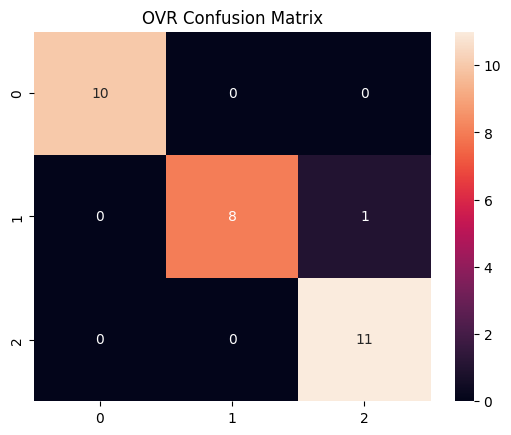

In [9]:
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix 
import seaborn as sns 

cm_ovr = confusion_matrix(y_test, y_pred_ovr)

sns.heatmap(cm_ovr, annot=True, fmt="d")
plt.title("OVR Confusion Matrix")
plt.show()

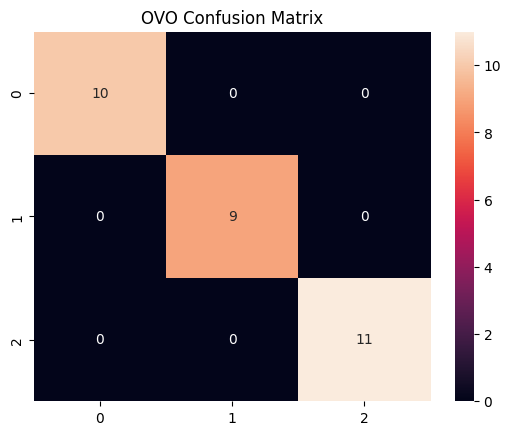

In [11]:
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix 
import seaborn as sns 

cm_ovo = confusion_matrix(y_test, y_pred_ovo)

sns.heatmap(cm_ovo, annot=True, fmt="d")
plt.title("OVO Confusion Matrix")
plt.show()

# Modellar soni bo`yicha OVR OVO ni ko`rish

# OVR dagi modellar soni 

In [12]:
len(ovr_model.estimators_)

3

# OVO dagi modellar soni 

In [13]:
len(ovo_model.estimators_)

3

# Decision Boundary -- Qaror chegarasini aniqlash 

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


c:\Users\Rasulbekk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Rasulbekk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Rasulbekk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


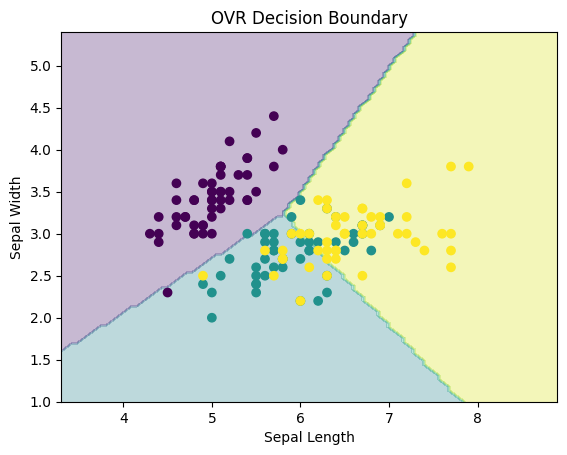

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target


x_small = X[['sepal length (cm)', 'sepal width (cm)']]


x_train, X_test, y_train, y_test = train_test_split(
    x_small, y, test_size=0.2, random_state=42
)


model = OneVsRestClassifier(LogisticRegression())
model.fit(x_train, y_train)


x_min, x_max = x_small.iloc[:,0].min()-1, x_small.iloc[:,0].max()+1
y_min, y_max = x_small.iloc[:,1].min()-1, x_small.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(x_small.iloc[:,0], x_small.iloc[:,1], c=y)
plt.title("OVR Decision Boundary")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()